In [1]:
from pymutspec import draw
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
from scipy.stats import ttest_ind, wilcoxon, mannwhitneyu, f_oneway, zscore, spearmanr
from scipy.spatial.distance import pdist, cdist
import re
import tarfile

In [2]:
# Swap that to True if you want to invert nucls
INVERT = True
#Change to true to filter mutspecs by num of total muts and num of mut types
FILTER = True

In [3]:
def filtering(mutspec12, meta_df, at_least_n_muts=15, at_least_n_mut_types=4, ms_type=12, filter_mut_types=True):
    #removing species with less than 15 total mutations - might need to bump up for all insects (do not do it for termites)
    mut_ammount_df = mutspec12.groupby(mutspec12['Species']).aggregate({'ObsNum' : 'sum'}).reset_index()
    less_than_15_total_muts = mut_ammount_df.drop(mut_ammount_df[mut_ammount_df['ObsNum'] > at_least_n_muts].index)['Species'].to_list()
    for sp in less_than_15_total_muts:
        mutspec12 = mutspec12.drop(mutspec12[mutspec12['Species'] == sp].index)
        meta_df = meta_df.drop(meta_df[meta_df['Species'] == sp].index)

    if filter_mut_types == False:
        return mutspec12, meta_df
    
    #removing species with less than 4 mutation types - might need to bump up for all insects (do not do it for termites)
    species = mutspec12['Species'].drop_duplicates().to_list()
    obsnum_values = mutspec12['ObsNum'].to_list()
    chopped_obsnum =  list(chop(obsnum_values, ms_type))
    
    species_and_obsnum = {}
    for i in range(len(species)):
        species_and_obsnum[species[i]] = chopped_obsnum[i]
    
    less_than_4_mut_types = []
    for sp, obsnum_list in species_and_obsnum.items():
        if obsnum_list.count(0) > 12 - at_least_n_mut_types: # 8 for less than 4 mut types, 4 is less than 8 mut types, 2 is less than 10 mut types, 0 for less than 12 mut type, i.e. all mut types are present
            less_than_4_mut_types.append(sp)
    
    for sp in less_than_4_mut_types:
        mutspec12 = mutspec12.drop(mutspec12[mutspec12['Species'] == sp].index)
        meta_df = meta_df.drop(meta_df[meta_df['Species'] == sp].index)

    return mutspec12, meta_df

def inverter(mutspec12):
    # inverts nucls for ms12, needs to be run only once. DEW IT :3
    # TODO - make it like inverter192 or not, idc
    a_spec = pd.concat([mutspec12[mutspec12['Mut'] == 'A>G'], mutspec12[mutspec12['Mut'] == 'A>C'], mutspec12[mutspec12['Mut'] == 'A>T']])
    t_spec = pd.concat([mutspec12[mutspec12['Mut'] == 'T>G'], mutspec12[mutspec12['Mut'] == 'T>C'], mutspec12[mutspec12['Mut'] == 'T>A']])
    g_spec = pd.concat([mutspec12[mutspec12['Mut'] == 'G>T'], mutspec12[mutspec12['Mut'] == 'G>C'], mutspec12[mutspec12['Mut'] == 'G>A']])
    c_spec = pd.concat([mutspec12[mutspec12['Mut'] == 'C>T'], mutspec12[mutspec12['Mut'] == 'C>G'], mutspec12[mutspec12['Mut'] == 'C>A']])

    a_spec.loc[a_spec['Mut'] == 'A>G', 'Mut'] = 'T>C'
    a_spec.loc[a_spec['Mut'] == 'A>C', 'Mut'] = 'T>G'
    a_spec.loc[a_spec['Mut'] == 'A>T', 'Mut'] = 'T>A'

    t_spec.loc[t_spec['Mut'] == 'T>G', 'Mut'] = 'A>C'
    t_spec.loc[t_spec['Mut'] == 'T>C', 'Mut'] = 'A>G'
    t_spec.loc[t_spec['Mut'] == 'T>A', 'Mut'] = 'A>T'

    g_spec.loc[g_spec['Mut'] == 'G>T', 'Mut'] = 'C>A'
    g_spec.loc[g_spec['Mut'] == 'G>C', 'Mut'] = 'C>G'
    g_spec.loc[g_spec['Mut'] == 'G>A', 'Mut'] = 'C>T'

    c_spec.loc[c_spec['Mut'] == 'C>T', 'Mut'] = 'G>A'
    c_spec.loc[c_spec['Mut'] == 'C>G', 'Mut'] = 'G>C'
    c_spec.loc[c_spec['Mut'] == 'C>A', 'Mut'] = 'G>T'

    mutspec12 = pd.concat([a_spec, t_spec, g_spec, c_spec]).sort_values(by=['Species', 'Mut'])
    return mutspec12

In [4]:
PATH_TO_FOLDER = '../data/'
ter_mi = pd.read_csv(f'{PATH_TO_FOLDER}latest_ter_midori_ms/filtered_ms12syn_iqtree.tsv', sep='\t').sort_values(by=['Species', 'Mut'])
nonter_mi = pd.read_csv(f'{PATH_TO_FOLDER}latest_nonter_midori_ms/filtered_ms12syn_iqtree.tsv', sep='\t').sort_values(by=['Species', 'Mut'])
ter_meta = pd.read_csv(f'{PATH_TO_FOLDER}latest_ter_midori_ms/msMetaData.tsv', sep='\t').sort_values(by=['Species'])
nonter_meta = pd.read_csv(f'{PATH_TO_FOLDER}latest_nonter_midori_ms/msMetaData.tsv', sep='\t').sort_values(by=['Species'])

ter_mi = ter_mi.dropna()
nonter_mi = nonter_mi.dropna()

if INVERT == True:
    ter_mi = inverter(ter_mi)
    nonter_mi = inverter(nonter_mi)

if FILTER == True:
    ter_mi, ter_meta = filtering(ter_mi, ter_meta, at_least_n_muts=10, filter_mut_types=False)
    nonter_mi, nonter_meta = filtering(nonter_mi, nonter_meta, at_least_n_muts=10, filter_mut_types=False)

In [5]:
ter_meta

,Species,Class,Order,Family,Genus,Nodes_in_tree
16,Anacanthotermes_ochraceus,Insecta,Blattodea,Hodotermitidae,Anacanthotermes,26.0
37,Ancistrotermes_pakistanicus,NaN,NaN,NaN,NaN,7.0
55,Anoplotermes_janus,NaN,NaN,NaN,NaN,7.0
42,Compositermes_vindai,Insecta,Blattodea,Termitidae,Compositermes,11.0
24,Coptotermes_acinaciformis,Insecta,Blattodea,Rhinotermitidae,Coptotermes,60.0
9,Coptotermes_frenchi,NaN,NaN,NaN,NaN,6.0
31,Coptotermes_gestroi,Insecta,Blattodea,Rhinotermitidae,Coptotermes,19.0
44,Coptotermes_heimi,Insecta,Blattodea,Rhinotermitidae,Coptotermes,11.0
19,Heterotermes_tenuis,Insecta,Blattodea,Rhinotermitidae,Heterotermes,13.0
17,Macrotermes_subhyalinus,Insecta,Blattodea,Termitidae,Macrotermes,17.0


In [6]:
len(ter_mi['Species'].unique())

20

In [7]:
len(nonter_mi['Species'].unique())

20

In [8]:
color_mapping12 = {
    "C>A": "deepskyblue",
    "G>T": "deepskyblue",
    "C>G": "black",
    "G>C": "black",
    "C>T": "red",
    "G>A": "red",
    "T>A": "silver",
    "A>T": "silver",
    "T>C": "yellowgreen",
    "A>G": "yellowgreen",
    "T>G": "pink",
    "A>C": "pink",
}
sbs12_ordered = ["C>A", "G>T", "C>G", "G>C", "C>T", "G>A", "T>A", "A>T", "T>C", "A>G", "T>G", "A>C"]
colors12 = [color_mapping12[sbs] for sbs in sbs12_ordered]

In [9]:
ter_mi

,Species,Mut,ExpNum,MutSpec,ObsNum
199,Anacanthotermes_ochraceus,A>C,11.74520,0.081589,1.958796
198,Anacanthotermes_ochraceus,A>G,40.69540,0.021584,1.795407
197,Anacanthotermes_ochraceus,A>T,11.74520,0.237921,5.711995
200,Anacanthotermes_ochraceus,C>A,5.71205,0.084014,0.980930
201,Anacanthotermes_ochraceus,C>G,5.71205,0.000000,0.000000
...,...,...,...,...,...
310,Trinervitermes_geminatus,G>C,14.67210,0.000000,0.000000
304,Trinervitermes_geminatus,G>T,14.67210,0.000000,0.000000
306,Trinervitermes_geminatus,T>A,100.49100,0.011822,0.322340
300,Trinervitermes_geminatus,T>C,139.53800,0.100865,3.818814


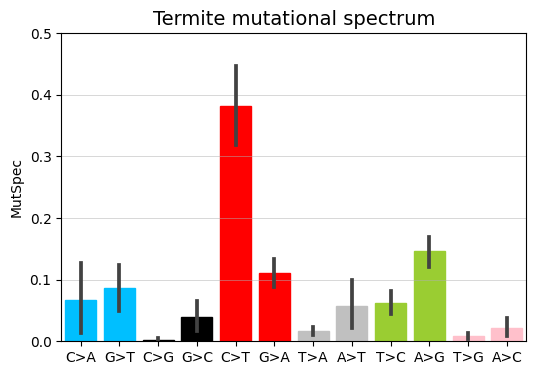

In [13]:
fig = plt.figure(figsize=(6, 4))
ax = fig.gca()
ax = sns.barplot(data=ter_mi, x="Mut", y="MutSpec", 
                        order=sbs12_ordered, ax=ax)
ax.grid(axis="y", alpha=.7, linewidth=0.5)

# map colors to bars
for bar, clr in zip(ax.patches, colors12):
    bar.set_color(clr)

ax.set_title('Termite mutational spectrum', fontsize=14)
ax.set_xlabel("")
ax.set_ylim([0, 0.5])

#plt.xticks(fontsize=8)
plt.savefig('../figures/term_mutspec.pdf', bbox_inches="tight")
plt.show()
plt.close()

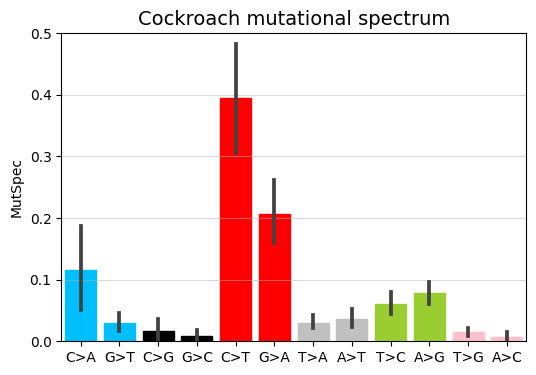

In [14]:
fig = plt.figure(figsize=(6, 4))
ax = fig.gca()
ax = sns.barplot(data=nonter_mi, x="Mut", y="MutSpec", 
                        order=sbs12_ordered, ax=ax)
ax.grid(axis="y", alpha=.7, linewidth=0.5)

# map colors to bars
for bar, clr in zip(ax.patches, colors12):
    bar.set_color(clr)

ax.set_title('Cockroach mutational spectrum', fontsize=14)
ax.set_xlabel("")
ax.set_ylim([0, 0.5])

#plt.xticks(fontsize=8)
plt.savefig('../figures/nonterm_mutspec.pdf', bbox_inches="tight")
plt.show()
plt.close()